Pré-dimensionamento de uma estrutura 2D por modelo de duas barras.

Modelo preliminar:
- chapa de espessura fixa;
- duas barras ideais ligadas ao ponto de aplicação da força;
- ângulos orientados das barras e da força medidos em relação à horizontal;
- N > 0 = tração; N < 0 = compressão;
- flambagem de Euler considerada FORA DO PLANO da chapa;
- para flambagem fora do plano: I = w*t^3/12;
- o fator de segurança é aplicado explicitamente;
- permite varrer vários ângulos da força e procurar os melhores
  pares de ângulos das barras.

IMPORTANTE:
Este é um modelo de pré-dimensionamento. A peça real não é uma
treliça ideal e uma lâmina de compósito pode exigir um modelo
ortotrópico/laminado e análise de concentrações de tensão, flambagem
de placa e região do furo em uma etapa posterior.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray

---
# Propriedades da chapa

In [2]:
PROPRIEDADES_CHAPA = {
    "espessura": 5e-3,          # m
    "sigma_tracao": 513e6,      # Pa (resistência estimada)
    "sigma_compressao": 473e6,  # Pa (resistência estimada)
    "modulo_young": 59e9,       # Pa
}

---
# Simulador

## Classe do Simulador

In [65]:
class SimuladorTrelica:
    """
    Modelo de duas barras para pré-dimensionamento.

    Convenção angular:
        theta = ângulo orientado em relação à horizontal.

    Convenção angular:
        theta_1, theta_2 e phi são ângulos convencionais, medidos
        positivamente no sentido anti-horário a partir do eixo +x.

    Na geometria de referência, o ponto de aplicação da força é
        P = (0, h_h)
    e os apoios das barras estão sobre o eixo x. Portanto, para uma
    barra com 0 < theta < 180 graus, sua coordenada do apoio é

        x_apoio = -h_h / tan(theta).

    Assim, barras com theta < 90 graus ficam à esquerda de P, enquanto
    barras com theta > 90 graus ficam à direita. Isso permite investigar
    a passagem de uma inclinação para a outra sem mudar a convenção.

    Convenção dos esforços:
        N > 0 -> tração
        N < 0 -> compressão

    Convenção da força:
        phi = 0 graus   -> F aponta para +x
        phi = 90 graus  -> F aponta para +y
        phi = 180 graus -> F aponta para -x

    As fórmulas analíticas usadas para os esforços são:

        N1 = F * sin(theta2 - phi) / sin(theta2 - theta1)
        N2 = F * sin(phi - theta1) / sin(theta2 - theta1)

    Elas são obtidas do equilíbrio do nó P com a convenção de sinais
    acima.
    """

    def __init__(
        self,
        altura_furo: float,
        forca: float,
        angulos_barras_deg: tuple[float, float],
        angulos_forca_deg: tuple[float, float, float] = (-30.0, 30.1, 5.0),
        propriedades: dict = PROPRIEDADES_CHAPA,
        fator_seguranca: float = 1.5,
        fator_k_flambagem: float = 1.0,
        b_h_min: float | None = None,
    ) -> None:

        self.h = float(altura_furo)
        self.F = float(forca)
        self.propriedades = propriedades
        self.SF = float(fator_seguranca)
        self.K = float(fator_k_flambagem)
        self.b_h_min = b_h_min

        if self.h <= 0:
            raise ValueError("altura_furo deve ser positiva.")

        if self.F <= 0:
            raise ValueError("forca deve ser positiva.")

        if self.SF <= 0:
            raise ValueError("fator_seguranca deve ser positivo.")

        if self.K <= 0:
            raise ValueError("fator_k_flambagem deve ser positivo.")

        if len(angulos_barras_deg) != 2:
            raise ValueError("São necessários exatamente dois ângulos de barras.")

        self.theta_barras_rad = np.deg2rad(
            np.asarray(angulos_barras_deg, dtype=float)
        )

        self.theta_forca_rad = np.deg2rad(
            np.arange(*angulos_forca_deg)
        )

        # Para L = h/|sin(theta)|, evitamos theta próximo de 0 ou 180 graus.
        if np.any(np.isclose(np.sin(self.theta_barras_rad), 0.0)):
            raise ValueError(
                "Ângulos das barras muito próximos de 0 ou 180 graus "
                "produzem comprimento infinito."
            )

        # Duas barras paralelas/colineares não permitem resolver o equilíbrio.
        if np.isclose(
            np.sin(self.theta_barras_rad[1] - self.theta_barras_rad[0]),
            0.0,
        ):
            raise ValueError(
                "Os ângulos das duas barras não podem ser iguais ou colineares."
            )

    # -----------------------------------------------------------------
    # PROPRIEDADES DO MATERIAL
    # -----------------------------------------------------------------

    @property
    def sigma_adm_tracao(self) -> float:
        """Tensão admissível à tração após aplicação do fator de segurança."""
        return self.propriedades["sigma_tracao"] / self.SF

    @property
    def sigma_adm_compressao(self) -> float:
        """Tensão admissível à compressão após aplicação do fator de segurança."""
        return self.propriedades["sigma_compressao"] / self.SF

    # -----------------------------------------------------------------
    # GEOMETRIA
    # -----------------------------------------------------------------

    @property
    def comprimentos_barras(self) -> NDArray:
        """
        Comprimentos das barras.

        Como theta é o ângulo da reta suporte em relação ao +x:

            L = h / sin(theta), 0° < theta < 180°
        """
        return self.h / np.sin(self.theta_barras_rad)

    @property
    def coord_barras_chao(self) -> NDArray:
        """
        Coordenadas horizontais dos pontos onde as barras encontram
        o chão, tomando a projeção vertical do furo como x = 0.

        Pela geometria da figura:

            x_apoio = -h / tan(theta)

        Portanto:
            theta < 90° -> apoio à esquerda (x < 0)
            theta > 90° -> apoio à direita (x > 0)
            theta = 90° -> apoio exatamente abaixo de P (x = 0)
                """
        return -self.h / np.tan(self.theta_barras_rad)

    @property
    def distancia_frontal(self) -> float:
        """
        Distância horizontal entre a projeção vertical do furo e o apoio
        mais próximo.

        Esta grandeza é usada como interpretação de b_h para impor uma
        distância mínima do furo à base.
        """
        return float(np.min(np.abs(self.coord_barras_chao)))

    def geometria_valida(self) -> bool:
        """
        Verifica condições geométricas básicas.

        1. Se b_h_min foi fornecido, o apoio mais à esquerda deve estar
           pelo menos b_h_min distante da projeção do furo.
        """
        if self.b_h_min is not None:
            if self.distancia_frontal < self.b_h_min:
                return False

        return True

    # -----------------------------------------------------------------
    # ESFORÇOS INTERNOS
    # -----------------------------------------------------------------

    @property
    def esforcos_internos(self) -> NDArray:
        """
        Calcula os esforços axiais pelas fórmulas analíticas:

            N1 = F * sin(theta2 - theta_f) / sin(theta2 - theta1)

            N2 = F * sin(theta_f - theta1) / sin(theta2 - theta1)

        Retorno:
            array (n_forcas, 2)

            coluna 0 -> N1
            coluna 1 -> N2

        N > 0: tração
        N < 0: compressão
        """
        theta_1, theta_2 = self.theta_barras_rad
        theta_f = self.theta_forca_rad

        denominador = np.sin(theta_2 - theta_1)

        N1 = (
            self.F
            * np.sin(theta_2 - theta_f)
            / denominador
        )

        N2 = (
            self.F
            * np.sin(theta_f - theta_1)
            / denominador
        )

        return np.column_stack((N1, N2))

    # -----------------------------------------------------------------
    # DIMENSIONAMENTO POR TENSÃO
    # -----------------------------------------------------------------

    @property
    def larguras_por_tensao(self) -> NDArray:
        """
        Largura mínima para satisfazer o critério de tensão axial:

            sigma = |N| / (w*t)

        A tensão admissível já inclui o fator de segurança.
        """
        N = self.esforcos_internos
        t = self.propriedades["espessura"]

        sigma_adm = np.where(
            N >= 0.0,
            self.sigma_adm_tracao,
            self.sigma_adm_compressao,
        )

        return np.abs(N) / (t * sigma_adm)

    # -----------------------------------------------------------------
    # FLAMBAGEM FORA DO PLANO
    # -----------------------------------------------------------------

    @property
    def larguras_por_flambagem(self) -> NDArray:
        """
        Dimensionamento por flambagem de Euler fora do plano.

        Se a seção da barra é:
            largura = w
            espessura = t

        então:

            I = w*t^3/12

        e:

            Pcr = pi^2*E*I/(K*L)^2

        Impõe-se:

            Pcr >= SF * |N|

        apenas para barras comprimidas.
        """
        N = self.esforcos_internos
        L = self.comprimentos_barras
        t = self.propriedades["espessura"]
        E = self.propriedades["modulo_young"]

        # Cada linha corresponde a um caso de força.
        # Cada coluna corresponde a uma barra.
        N_comp = np.maximum(-N, 0.0)

        largura = (
            (12.0 * self.SF * N_comp * (self.K * L[None, :]) ** 2)
            / 
            (np.pi**2 * E * t**3)
        )

        return largura

    # -----------------------------------------------------------------
    # LARGURA FINAL
    # -----------------------------------------------------------------

    @property
    def larguras_minimas(self) -> NDArray:
        """
        Para cada barra e caso de carga:

            w = max(w_tensao, w_flambagem)
        """
        return np.maximum(
            self.larguras_por_tensao,
            self.larguras_por_flambagem,
        )

    # -----------------------------------------------------------------
    # MATERIAL
    # -----------------------------------------------------------------

    @property
    def area_material(self) -> NDArray:
        """
        Área da chapa no plano 2D aproximada pelos dois caminhos de carga:

            A_material = sum(w_i * L_i)
        """
        L = self.comprimentos_barras
        w = self.larguras_minimas

        return np.sum(w * L[None, :], axis=1)

    @property
    def volume_material(self) -> NDArray:
        """Volume correspondente à área 2D vezes a espessura."""
        return self.area_material * self.propriedades["espessura"]

    # -----------------------------------------------------------------
    # RESUMO
    # -----------------------------------------------------------------

    def resultados(self) -> pd.DataFrame:
        """
        Retorna uma tabela com os resultados de cada ângulo da força.
        """
        N = self.esforcos_internos
        w_sigma = self.larguras_por_tensao
        w_buck = self.larguras_por_flambagem
        w = self.larguras_minimas

        df = pd.DataFrame({
            "theta_forca_deg": np.rad2deg(self.theta_forca_rad),

            "N1_N": N[:, 0],
            "N2_N": N[:, 1],

            "w1_tensao_m": w_sigma[:, 0],
            "w2_tensao_m": w_sigma[:, 1],

            "w1_flambagem_m": w_buck[:, 0],
            "w2_flambagem_m": w_buck[:, 1],

            "w1_final_m": w[:, 0],
            "w2_final_m": w[:, 1],

            "area_material_m2": self.area_material,
            "volume_material_m3": self.volume_material,
        })

        return df

## Visualizador da estrutura

In [66]:
def plotar_estrutura(
    h_h: float,
    x1: float,
    x2: float,
    N1: float,
    N2: float,
    ax=None,
    mostrar_valores: bool = True,
):
    """
    Plota a estrutura 2D simplificada como duas barras.

    Parâmetros
    ----------
    h_h : float
        Altura do centro do furo em relação à base [m].

    x1, x2 : float
        Coordenadas horizontais dos apoios das barras [m].
        O centro do furo está em x = 0.

    N1, N2 : float
        Esforços axiais nas barras [N].
        N > 0 -> tração  -> azul
        N < 0 -> compressão -> vermelho

    ax : matplotlib.axes.Axes, opcional
        Eixo existente. Se None, cria uma nova figura.

    mostrar_valores : bool
        Se True, mostra o valor do esforço sobre cada barra.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # ---------------------------------------------------------
    # PONTO DO FURO
    # ---------------------------------------------------------

    x_furo = 0.0
    y_furo = h_h

    # ---------------------------------------------------------
    # BASE
    # ---------------------------------------------------------

    x_min = min(x1, x2, 0.0)
    x_max = max(x1, x2, 0.0)

    margem = 0.1 * max(x_max - x_min, h_h)

    ax.plot(
        [x_min - margem, x_max + margem],
        [0, 0],
        color="black",
        linewidth=3,
        solid_capstyle="butt",
    )

    # ---------------------------------------------------------
    # BARRAS
    # ---------------------------------------------------------

    def desenhar_barra(x, N, numero):
        if N > 0:
            cor = "blue"
            estado = "Tração"
        elif N < 0:
            cor = "red"
            estado = "Compressão"
        else:
            cor = "gray"
            estado = "Carga nula"

        ax.plot(
            [x, x_furo],
            [0, y_furo],
            color=cor, linewidth=5,
            solid_capstyle="round",
        )

        if mostrar_valores:
            # Ponto aproximadamente no meio da barra
            xm = x / 2
            ym = h_h / 2
            ax.text(
                xm, ym,
                f"N{numero} = {N:.2f} N",
                fontsize=10, ha="center", va="bottom", color=cor,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8,
                    pad=2,
                ),
            )

    desenhar_barra(x1, N1, 1)
    desenhar_barra(x2, N2, 2)

    # ---------------------------------------------------------
    # FURO E APOIOS
    # ---------------------------------------------------------

    ax.scatter(
        [x_furo, x1, x2],
        [y_furo, 0,  0],
        s=50,
        color="black",
        zorder=5,
    )

    # ---------------------------------------------------------
    # EIXOS
    # ---------------------------------------------------------

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.3)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.3)

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")

    ax.set_aspect("equal", adjustable="box")

    ax.set_xlim(
        x_min - margem,
        x_max + margem,
    )

    ax.set_ylim(
        -0.05 * h_h,
         1.15 * h_h,
    )

    ax.grid(True, alpha=0.2)

    ax.set_title("Modelo simplificado da estrutura")

    return ax

## Varredura de ângulos

In [67]:
def varrer_angulos(
    altura_furo: float,
    forca: float,
    thetas_deg: NDArray,
    angulos_forca_deg: tuple[float, float, float] = (-30.0, 30.1, 5.0),
    propriedades: dict = PROPRIEDADES_CHAPA,
    fator_seguranca: float = 1.5,
    fator_k_flambagem: float = 1.0,
    b_h_min: float | None = None,
) -> pd.DataFrame:
    """
    Testa todas as combinações de theta1 e theta2.

    Uma configuração só é aceita se a restrição b_h_min,
    quando fornecida, for satisfeita.

    O custo de uma configuração é o pior caso de área de material
    entre todos os ângulos de força testados.
    """

    resultados = []

    for theta1 in thetas_deg[1:]:
        for theta2 in thetas_deg[thetas_deg < theta1]:
            try:
                simulador = SimuladorTrelica(
                    altura_furo=altura_furo,
                    forca=forca,
                    angulos_barras_deg=(theta1, theta2),
                    angulos_forca_deg=angulos_forca_deg,
                    propriedades=propriedades,
                    fator_seguranca=fator_seguranca,
                    fator_k_flambagem=fator_k_flambagem,
                    b_h_min=b_h_min,
                )

            except ValueError:
                continue

            if not simulador.geometria_valida():
                continue

            df = simulador.resultados()

            # Critério conservador:
            # a geometria deve ser dimensionada para o pior caso de carga.
            idx_pior = df["area_material_m2"].idxmax()

            resultados.append({
                "theta1_deg": theta1,
                "theta2_deg": theta2,

                "x1_mm": 1000 * simulador.coord_barras_chao[0],
                "x2_mm": 1000 * simulador.coord_barras_chao[1],

                "L1_mm": 1000 * simulador.comprimentos_barras[0],
                "L2_mm": 1000 * simulador.comprimentos_barras[1],

                "area_pior_caso_mm2": round(
                    1000**2 *  df.loc[idx_pior, "area_material_m2"],
                    2
                ),

                "volume_pior_caso_mm3": round(
                    1000**3 * df.loc[idx_pior, "volume_material_m3"],
                    2
                ),

                "theta_forca_pior_caso_deg": df.loc[
                    idx_pior, "theta_forca_deg"
                ],

                "w1_pior_mm": round(1000 * df.loc[idx_pior, "w1_final_m"], 2),
                "w2_pior_mm": round(1000 * df.loc[idx_pior, "w2_final_m"], 2),

                "N1_pior_N": round(df.loc[idx_pior, "N1_N"], 2),
                "N2_pior_N": round(df.loc[idx_pior, "N2_N"], 2),
            })

    return (
        pd.DataFrame(resultados)
        .sort_values("area_pior_caso_mm2")
        .reset_index(drop=True)
    )

In [68]:
def varrer_angulos(
    altura_furo: float,
    forca: float,
    thetas_deg: NDArray,
    angulos_forca_deg: tuple[float, float, float] = (-30.0, 30.1, 5.0),
    propriedades: dict = PROPRIEDADES_CHAPA,
    fator_seguranca: float = 1.5,
    fator_k_flambagem: float = 1.0,
    b_h_min: float | None = None,
) -> pd.DataFrame:
    """
    Testa todas as combinações de theta1 e theta2.

    Uma configuração só é aceita se a restrição b_h_min,
    quando fornecida, for satisfeita.

    O custo de uma configuração é o pior caso de área de material
    entre todos os ângulos de força testados.
    """

    resultados = []

    for theta1 in thetas_deg[1:]:
        for theta2 in thetas_deg[thetas_deg < theta1]:
            try:
                simulador = SimuladorTrelica(
                    altura_furo=altura_furo,
                    forca=forca,
                    angulos_barras_deg=(theta1, theta2),
                    angulos_forca_deg=angulos_forca_deg,
                    propriedades=propriedades,
                    fator_seguranca=fator_seguranca,
                    fator_k_flambagem=fator_k_flambagem,
                    b_h_min=b_h_min,
                )

            except ValueError:
                continue

            if not simulador.geometria_valida():
                continue

            df = simulador.resultados()

            # Critério conservador:
            # a geometria deve ser dimensionada para o pior caso de carga.
            idx_pior = df["area_material_m2"].idxmax()

            resultados.append({
                "theta1_deg": theta1,
                "theta2_deg": theta2,

                "x1_mm": 1000 * simulador.coord_barras_chao[0],
                "x2_mm": 1000 * simulador.coord_barras_chao[1],

                "L1_mm": 1000 * simulador.comprimentos_barras[0],
                "L2_mm": 1000 * simulador.comprimentos_barras[1],

                "b_h_mm": -1000 * simulador.coord_barras_chao[0],

                "area_pior_caso_mm2": 1000**2 *  df.loc[
                    idx_pior, "area_material_m2"
                ],

                "volume_pior_caso_mm3": 1000**3 * df.loc[
                    idx_pior, "volume_material_m3"
                ],

                "theta_forca_pior_caso_deg": df.loc[
                    idx_pior, "theta_forca_deg"
                ],

                "w1_pior_mm": 1000 * df.loc[idx_pior, "w1_final_m"],
                "w2_pior_mm": 1000 * df.loc[idx_pior, "w2_final_m"],

                "N1_pior_N": df.loc[idx_pior, "N1_N"],
                "N2_pior_N": df.loc[idx_pior, "N2_N"],
            })

    return (
        pd.DataFrame(resultados)
        .sort_values("area_pior_caso_mm2")
        .reset_index(drop=True)
        .map(lambda x: round(x, 2))
    )

---
# Aplicação

## 1. Parâmetros

In [96]:
h_h = 30 / 1000 # m
F = 300.0       # N

SF = 2
K = 2.0  # Fator K de flambagem

# Distância mínima entre a projeção vertical do furo e o apoio
# mais próximo:
b_h = 20 / 1000  # m

# Angulação das forças para teste
angulos_forca = (-40.0, 40.1, 1.0)

## 2. Varredura

In [100]:
angulos_barras = np.arange(10.0, 100.1, 1.0)

resultados = varrer_angulos(
    altura_furo=h_h,
    forca=F,
    thetas_deg=angulos_barras,
    angulos_forca_deg=angulos_forca,
    propriedades=PROPRIEDADES_CHAPA,
    fator_seguranca=SF,
    fator_k_flambagem=K,
    b_h_min=b_h,
)

if resultados.empty:
    raise ValueError("Nenhuma configuração satisfez as restrições geométricas.")

# ---------------------------------------------------------------
# MELHORES CONFIGURAÇÕES
# ---------------------------------------------------------------

colunas = [
    "theta1_deg",
    "theta2_deg",
    # "b_h_mm",
    "x1_mm",
    "x2_mm",
    "w1_pior_mm",
    "w2_pior_mm",
    "area_pior_caso_mm2",
    "theta_forca_pior_caso_deg",
]

resultados[colunas].head(10)

,theta1_deg,theta2_deg,x1_mm,x2_mm,w1_pior_mm,w2_pior_mm,area_pior_caso_mm2,theta_forca_pior_caso_deg
0,56.0,19.0,-20.24,-87.13,0.74,0.39,62.32,-40.0
1,56.0,20.0,-20.24,-82.42,0.76,0.40,62.34,-40.0
2,56.0,18.0,-20.24,-92.33,0.71,0.38,62.51,-40.0
3,56.0,21.0,-20.24,-78.15,0.79,0.41,62.54,-40.0
4,56.0,17.0,-20.24,-98.13,0.69,0.37,62.92,-40.0
5,56.0,22.0,-20.24,-74.25,0.82,0.42,62.92,-40.0
6,56.0,23.0,-20.24,-70.68,0.85,0.43,63.47,-40.0
7,56.0,16.0,-20.24,-104.62,0.67,0.36,63.57,-40.0
8,56.0,24.0,-20.24,-67.38,0.88,0.44,64.18,-40.0
9,56.0,15.0,-20.24,-111.96,0.65,0.35,64.51,-40.0


## 3. Melhor resultado

=== MELHOR CONFIGURAÇÃO ===
theta1 = 56.00°
theta2 = 19.00°
L1     = 36.19 mm
L2     = 92.15 mm
w1     = 0.74 mm
w2     = 0.39 mm
Área 2D = 62.32 mm²
Força crítica = -40.00°

=== DETALHAMENTO DA MELHOR CONFIGURAÇÃO ===



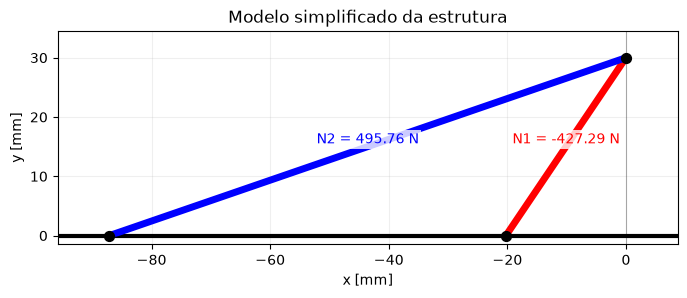

,theta_forca_deg,N1_N,N2_N,w1_tensao_m,w2_tensao_m,w1_flambagem_m,w2_flambagem_m,w1_final_m,w2_final_m,area_material_m2,volume_material_m3
0,-40.0,-427.291078,495.761251,0.000361,0.000387,0.000738,0.0,0.000738,0.000387,0.000062,3.116197e-07
1,-39.0,-422.745227,496.595130,0.000358,0.000387,0.000730,0.0,0.000730,0.000387,0.000062,3.104988e-07
2,-38.0,-418.070604,497.277741,0.000354,0.000388,0.000722,0.0,0.000722,0.000388,0.000062,3.092833e-07
3,-37.0,-413.268633,497.808876,0.000349,0.000388,0.000714,0.0,0.000714,0.000388,0.000062,3.079736e-07
4,-36.0,-408.340776,498.188374,0.000345,0.000388,0.000705,0.0,0.000705,0.000388,0.000061,3.065700e-07
...,...,...,...,...,...,...,...,...,...,...,...
76,36.0,145.744968,170.494320,0.000114,0.000133,0.000000,0.0,0.000114,0.000133,0.000016,8.181083e-08
77,37.0,154.042513,162.293134,0.000120,0.000127,0.000000,0.0,0.000120,0.000127,0.000016,8.003519e-08
78,38.0,162.293134,154.042513,0.000127,0.000120,0.000000,0.0,0.000127,0.000120,0.000016,7.823517e-08
79,39.0,170.494320,145.744968,0.000133,0.000114,0.000000,0.0,0.000133,0.000114,0.000015,7.641132e-08


In [101]:
melhor = resultados.iloc[0]

print("=== MELHOR CONFIGURAÇÃO ===")
print(f"theta1 = {melhor['theta1_deg']:.2f}°")
print(f"theta2 = {melhor['theta2_deg']:.2f}°")
print(f"L1     = {melhor['L1_mm']:.2f} mm")
print(f"L2     = {melhor['L2_mm']:.2f} mm")
print(f"w1     = {melhor['w1_pior_mm']:.2f} mm")
print(f"w2     = {melhor['w2_pior_mm']:.2f} mm")
print(f"Área 2D = {melhor['area_pior_caso_mm2']:.2f} mm²")
print(f"Força crítica = {melhor['theta_forca_pior_caso_deg']:.2f}°")

# ---------------------------------------------------------------
# DETALHE DA MELHOR CONFIGURAÇÃO
# ---------------------------------------------------------------

sim_melhor = SimuladorTrelica(
    altura_furo=h_h,
    forca=F,
    angulos_barras_deg=(
        melhor["theta1_deg"],
        melhor["theta2_deg"],
    ),
    angulos_forca_deg=angulos_forca,
    propriedades=PROPRIEDADES_CHAPA,
    fator_seguranca=SF,
    fator_k_flambagem=K,
    b_h_min=b_h,
)


print("\n=== DETALHAMENTO DA MELHOR CONFIGURAÇÃO ===\n")

plotar_estrutura(
    h_h=h_h * 1000,  # mm
    x1=melhor.x1_mm,
    x2=melhor.x2_mm,
    N1=melhor.N1_pior_N,
    N2=melhor.N2_pior_N,
)
plt.show()

sim_melhor.resultados()

---
## Visualização da estrutura

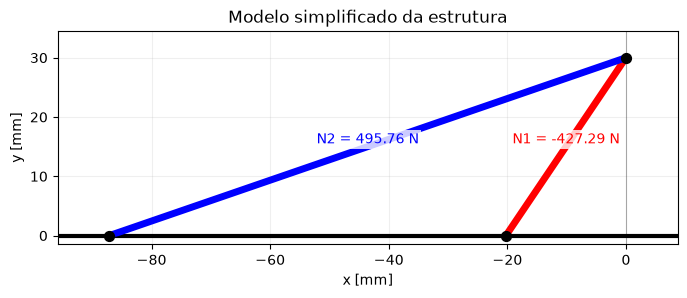

In [89]:
plotar_estrutura(
    h_h=h_h * 1000,  # mm
    x1=melhor.x1_mm,
    x2=melhor.x2_mm,
    N1=melhor.N1_pior_N,
    N2=melhor.N2_pior_N,
)

plt.show()

## Visualização de mapa de calor

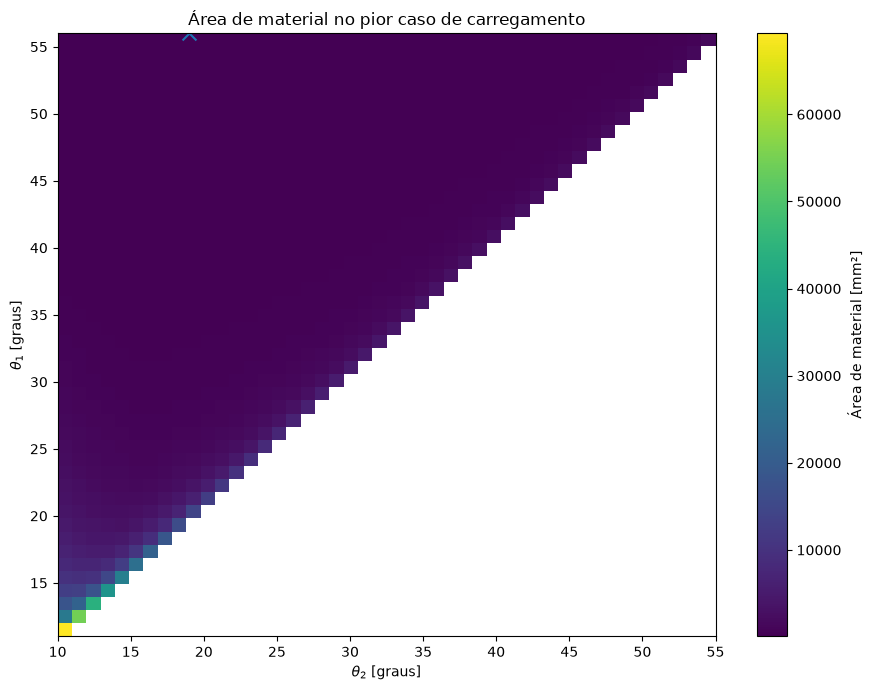

In [90]:
# ---------------------------------------------------------------
# MAPA DE CALOR
# ---------------------------------------------------------------

# Para visualizar o espaço de projeto, usamos os resultados
# aceitos pela restrição geométrica.
mapa = resultados.pivot(
    index="theta1_deg",
    columns="theta2_deg",
    values="area_pior_caso_mm2",
)

plt.figure(figsize=(9, 7))

imagem = plt.imshow(
    mapa.values,
    origin="lower",
    aspect="auto",
    extent=[
        mapa.columns.min(),
        mapa.columns.max(),
        mapa.index.min(),
        mapa.index.max(),
    ],
)

plt.colorbar(imagem, label="Área de material [mm²]")
plt.scatter(
    melhor["theta2_deg"],
    melhor["theta1_deg"],
    marker="x",
    s=100,
)

plt.xlabel(r"$\theta_2$ [graus]")
plt.ylabel(r"$\theta_1$ [graus]")
plt.title("Área de material no pior caso de carregamento")
plt.tight_layout()
plt.show()